*Section 0: Connect to Google Drive*

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Section 1: Setup and Load Dataset

In this section, I import the required Python libraries, upload the Bank Marketing dataset into Google Colab, and load it into a pandas DataFrame. This step confirms that the dataset is accessible and ready for further inspection and preprocessing.

In [2]:
# Import libraries

import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

print("Libraries imported successfully.")

Libraries imported successfully.


## **1.1** Upload the dataset file

Here, I upload the dataset file into the Colab session. I will upload the main CSV file from the Bank Marketing dataset so that it can be loaded and analysed in the following steps.

In [3]:
# Load dataset from Google Drive

import pandas as pd

file_path = "/content/drive/MyDrive/bank-full.csv"

df = pd.read_csv(file_path, sep=";")

print("Dataset loaded successfully.")
print("File path:", file_path)
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
File path: /content/drive/MyDrive/bank-full.csv
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## **1.2** Confirm target column

This cell verifies that the target variable is present and checks the class distribution for the binary classification task.

In [4]:
# Confirming target column

print("Columns:")
print(df.columns.tolist())

print("\nTarget value counts:")
print(df["y"].value_counts())

print("\nTarget proportions:")
print(df["y"].value_counts(normalize=True))

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target value counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target proportions:
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


# Section 2: Initial Data Inspection

In this section, I perform an initial inspection of the Bank Marketing dataset. The aim is to understand the dataset size, feature types, numerical summaries, and categorical variables before carrying out any cleaning, preprocessing, or exploratory data analysis.

In [5]:
# Check overall structure

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nDetailed info:")
df.info()

Dataset shape: (45211, 17)

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month   

## **2.1** Numerical feature summary

This cell provides descriptive statistics for the numerical features in the dataset. It helps identify the range, spread, and central tendency of the continuous and integer-based variables.

In [6]:
# Summary statistics for numerical columns

print("Numerical summary statistics:")
display(df.describe())

Numerical summary statistics:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## **2.2** Separate numerical and categorical features

This cell identifies which variables are numerical and which are categorical. This is important because both groups will require different preprocessing techniques later.

In [7]:
# Identify numerical and categorical columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Number of numerical columns: 7
Number of categorical columns: 10


## **2.3** Inspect unique values in categorical features

This cell checks the unique values present in each categorical variable. This helps identify important categories, possible inconsistencies, and special values such as 'unknown' that need attention.

In [8]:
# Unique values in categorical columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Number of unique values:", df[col].nunique())
    print("Unique values:", sorted(df[col].unique()))


Column: job
Number of unique values: 12
Unique values: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown']

Column: marital
Number of unique values: 3
Unique values: ['divorced', 'married', 'single']

Column: education
Number of unique values: 4
Unique values: ['primary', 'secondary', 'tertiary', 'unknown']

Column: default
Number of unique values: 2
Unique values: ['no', 'yes']

Column: housing
Number of unique values: 2
Unique values: ['no', 'yes']

Column: loan
Number of unique values: 2
Unique values: ['no', 'yes']

Column: contact
Number of unique values: 3
Unique values: ['cellular', 'telephone', 'unknown']

Column: month
Number of unique values: 12
Unique values: ['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may', 'nov', 'oct', 'sep']

Column: poutcome
Number of unique values: 4
Unique values: ['failure', 'other', 'success', 'unknown']

Column: y
Number of uniq

## **2.4** Check class balance

This cell reconfirms the class distribution of the target variable. This is useful because class imbalance will influence model training and evaluation choices later in the project.

In [9]:
# Target distribution summary

target_counts = df["y"].value_counts()
target_props = df["y"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_props.round(2))

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


# Section 3: Data Quality Checks

In this section, I evaluate the quality of the Bank Marketing dataset before carrying out exploratory data analysis and preprocessing. The checks include missing values, duplicate rows, unknown categories in categorical variables, and special coded values that may affect model training.

In [10]:
# Checking for missing values

missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percent
})

print("Missing values by column:")
display(missing_df)

Missing values by column:


,Missing Count,Missing Percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


## **3.1** Check for duplicate records

This cell identifies whether the dataset contains duplicate rows. Duplicate observations can bias model training and evaluation, so they need to be detected before further processing.

In [11]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:", round(duplicate_percent, 4), "%")

Number of duplicate rows: 0
Percentage of duplicate rows: 0.0 %


## **3.2** Identifying unknown categories

This cell checks how often the category 'unknown' appears in categorical features. Although these are not technically missing values, they still represent incomplete or uncertain information and may influence preprocessing decisions.

In [12]:
# Counting the 'unknown' values in categorical columns

unknown_summary = {}

for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    unknown_percent = (unknown_count / len(df)) * 100
    unknown_summary[col] = {
        "Unknown Count": unknown_count,
        "Unknown Percentage": round(unknown_percent, 2)
    }

unknown_df = pd.DataFrame(unknown_summary).T
print("Summary of 'unknown' values:")
display(unknown_df)

Summary of 'unknown' values:


,Unknown Count,Unknown Percentage
job,288.0,0.64
marital,0.0,0.00
education,1857.0,4.11
default,0.0,0.00
housing,0.0,0.00
loan,0.0,0.00
contact,13020.0,28.80
month,0.0,0.00
poutcome,36959.0,81.75
y,0.0,0.00


## **3.3** Inspecting special values in pdays

This cell investigates the variable 'pdays', where the value -1 commonly indicates that the client was not previously contacted. This is important because it is a coded category rather than a standard numerical measurement.

In [13]:
# Investigating special values in pdays

pdays_neg1_count = (df["pdays"] == -1).sum()
pdays_neg1_percent = (pdays_neg1_count / len(df)) * 100

print("Number of rows where pdays = -1:", pdays_neg1_count)
print("Percentage of rows where pdays = -1:", round(pdays_neg1_percent, 2), "%")

print("\nTop pdays value counts:")
print(df["pdays"].value_counts().head(10))

Number of rows where pdays = -1: 36954
Percentage of rows where pdays = -1: 81.74 %

Top pdays value counts:
pdays
-1      36954
 182      167
 92       147
 183      126
 91       126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64


## 3.4 Inspect suspicious numerical ranges

This cell checks the minimum and maximum values of numerical variables to identify unusually large ranges, negative values, and possible outliers that may need to be handled during preprocessing.

In [14]:
#Checking numerical ranges

range_summary = pd.DataFrame({
    "Minimum": df[numerical_cols].min(),
    "Maximum": df[numerical_cols].max(),
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median()
})

print("Numerical range summary:")
display(range_summary)

Numerical range summary:


,Minimum,Maximum,Mean,Median
age,18,95,40.936210,39.0
balance,-8019,102127,1362.272058,448.0
day,1,31,15.806419,16.0
duration,0,4918,258.163080,180.0
campaign,1,63,2.763841,2.0
pdays,-1,871,40.197828,-1.0
previous,0,275,0.580323,0.0


# Section 4: Exploratory Data Analysis (Part 1 - Target and Categorical Features)

In this section, I begin exploratory data analysis by examining the target variable and the main categorical predictors. The goal is to understand class imbalance and identify whether certain customer categories are associated with higher or lower subscription rates.

In [15]:
# Basic plotting setup

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## **4.1** Target class distribution

This cell visualises the distribution of the target variable to confirm the class imbalance between customers who subscribed and those who did not subscribe to the term deposit.

Target counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


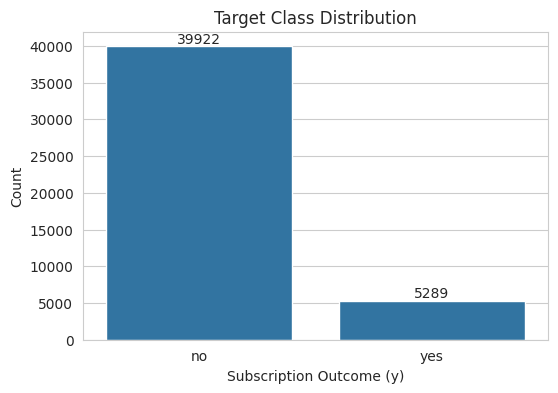

In [16]:
# Target distribution plot

target_counts = df["y"].value_counts()
target_percent = df["y"].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent.round(2))

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="y")
plt.title("Target Class Distribution")
plt.xlabel("Subscription Outcome (y)")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.show()

## **4.2** Subscription rate by job

This cell examines how the subscription rate varies across job categories. It helps identify whether occupation appears to influence the likelihood of subscribing to the term deposit.

Subscription rate by job (%):


,Subscription Rate (%)
job,
student,28.678038
retired,22.791519
unemployed,15.502686
management,13.755551
admin.,12.202669
self-employed,11.842939
unknown,11.805556
technician,11.056996
services,8.883004


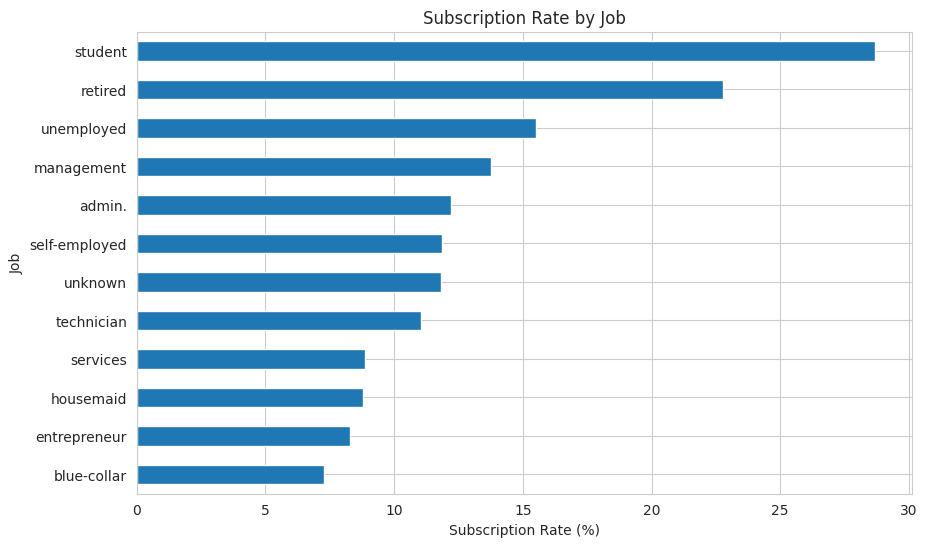

In [17]:
# Subscription rate by job

job_rate = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by job (%):")
display(job_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(10, 6))
job_rate.plot(kind="barh")
plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.gca().invert_yaxis()  # highest rate at top
plt.show()

## **4.3** Subscription rate by education

This cell compares subscription rates across education levels. It helps reveal whether educational background is associated with different customer response patterns.


Subscription rate by education (%):


,Subscription Rate (%)
education,
tertiary,15.006390
unknown,13.570275
secondary,10.559435
primary,8.626478


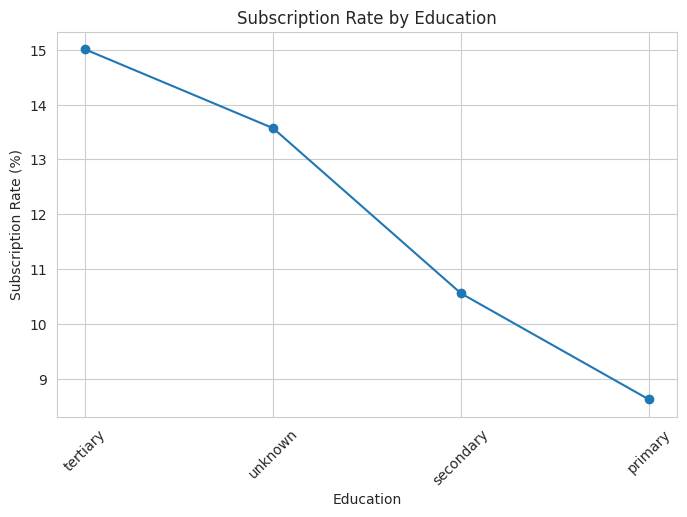

In [18]:
# Subscription rate by education

education_rate = (
    df.groupby("education")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by education (%):")
display(education_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(8, 5))
plt.plot(education_rate.index, education_rate.values, marker='o', linestyle='-')
plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.show()

## **4.4** Subscription rate by contact type

This cell investigates whether the communication contact type is associated with customer subscription behaviour. Since the variable contains many 'unknown' values, it is important to understand how this category behaves.

Subscription rate by contact type (%):


,Subscription Rate (%)
contact,
cellular,14.918900
telephone,13.420509
unknown,4.070661


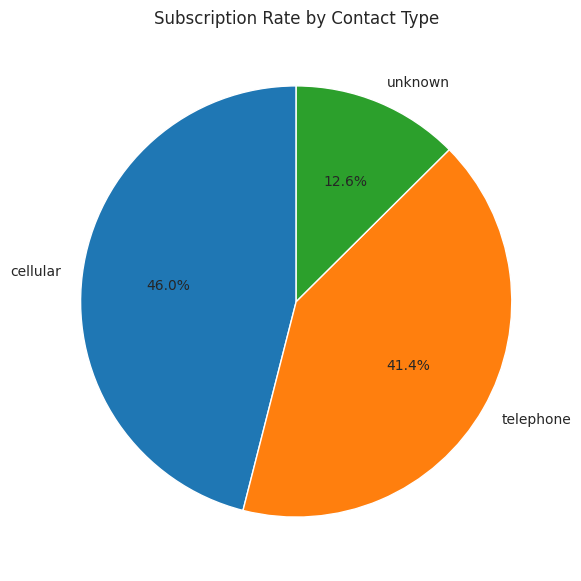

In [19]:
# Subscription rate by contact type

contact_rate = (
    df.groupby("contact")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by contact type (%):")
display(contact_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(7, 7))
plt.pie(contact_rate.values, labels=contact_rate.index, autopct='%1.1f%%', startangle=90)
plt.title("Subscription Rate by Contact Type")
plt.show()

## **4.5** Subscription rate by previous campaign outcome

This cell analyses the relationship between the outcome of the previous marketing campaign and the current subscription rate. This variable may be highly informative, even though many observations contain the category 'unknown'.

Subscription rate by previous campaign outcome (%):


,Subscription Rate (%)
poutcome,
success,64.725347
other,16.684783
failure,12.609671
unknown,9.161503


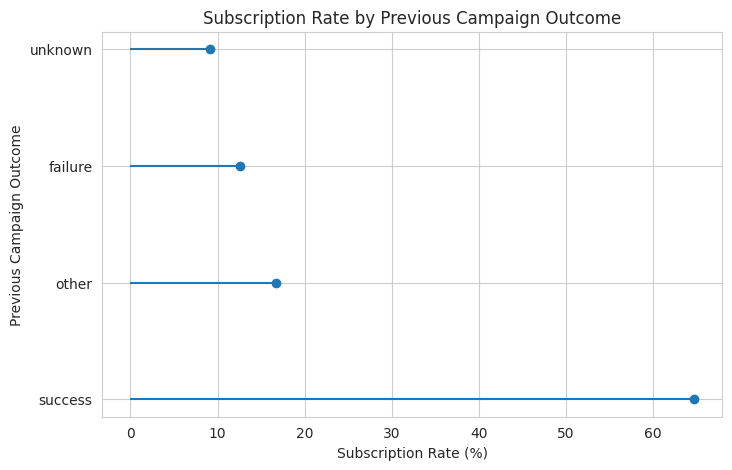

In [20]:
# Subscription rate by previous campaign outcome

poutcome_rate = (
    df.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
    * 100
)

print("Subscription rate by previous campaign outcome (%):")
display(poutcome_rate.to_frame(name="Subscription Rate (%)"))

plt.figure(figsize=(8, 5))
plt.hlines(y=poutcome_rate.index, xmin=0, xmax=poutcome_rate.values)
plt.plot(poutcome_rate.values, poutcome_rate.index, "o")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Previous Campaign Outcome")
plt.show()

In [21]:
# Compact insight summary

print("Top 3 job categories by subscription rate:")
print(job_rate.head(3).round(2))

print("\nEducation categories by subscription rate:")
print(education_rate.round(2))

print("\nContact types by subscription rate:")
print(contact_rate.round(2))

print("\nPrevious campaign outcome by subscription rate:")
print(poutcome_rate.round(2))

Top 3 job categories by subscription rate:
job
student       28.68
retired       22.79
unemployed    15.50
Name: y, dtype: float64

Education categories by subscription rate:
education
tertiary     15.01
unknown      13.57
secondary    10.56
primary       8.63
Name: y, dtype: float64

Contact types by subscription rate:
contact
cellular     14.92
telephone    13.42
unknown       4.07
Name: y, dtype: float64

Previous campaign outcome by subscription rate:
poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: y, dtype: float64


# Section 5: Exploratory Data Analysis (Part 2 - Numerical Features)

In this section, I analyse the numerical features in the Bank Marketing dataset. The aim is to understand their distributions, identify skewness and outliers, compare values across the target classes, and examine correlations between the numerical variables.

In [22]:
# Define numerical feature list for EDA

numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
print("Numerical features used for EDA:")
print(numerical_features)

Numerical features used for EDA:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## **5.1** Histograms of numerical variables

This section visualises the distributions of the numerical variables. It helps identify skewness, concentration of values, and unusually wide ranges that may affect later preprocessing and model training.

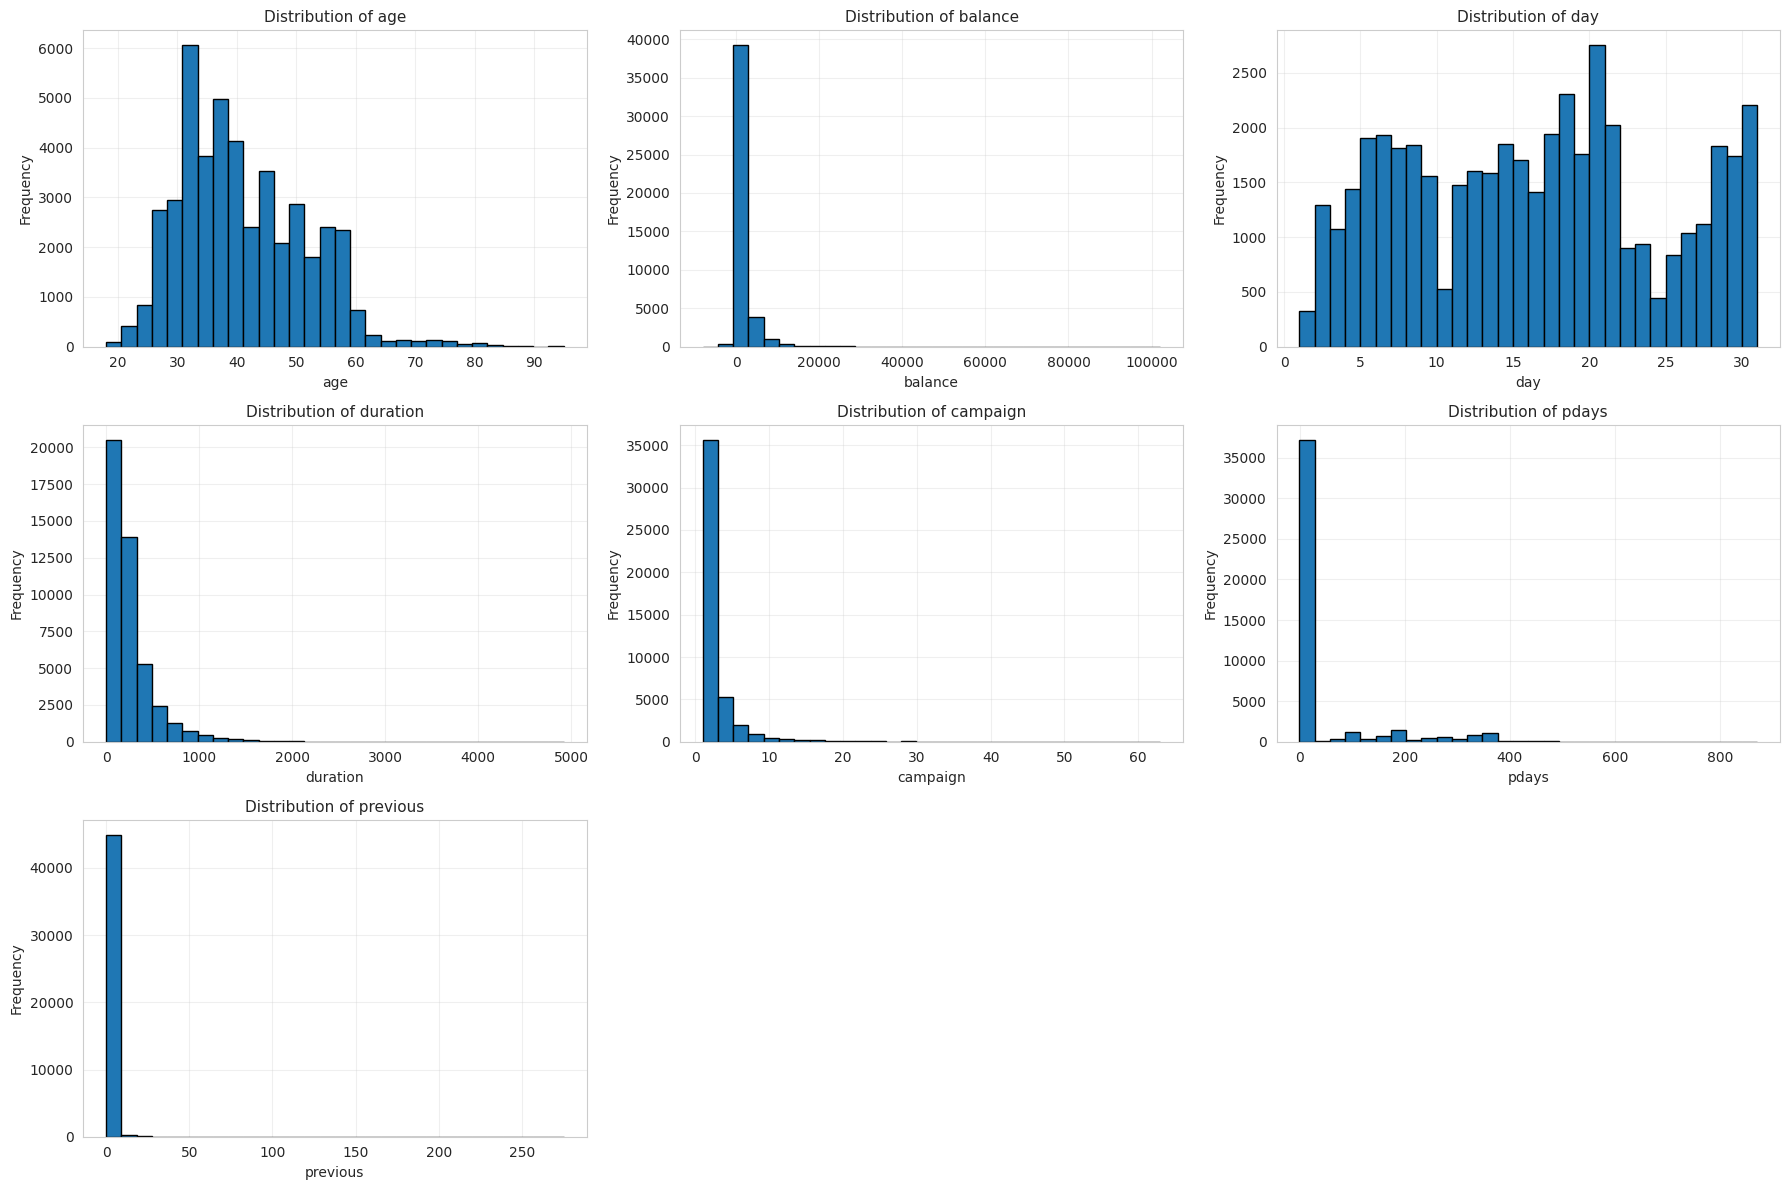

In [23]:
# Histograms for numerical variables

import math

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=30, edgecolor="black")
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True, alpha=0.3)

# Removing empty spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **5.2** Boxplots of numerical variables

This section uses boxplots to identify outliers and spread in the numerical variables. Boxplots are useful for spotting extreme values and comparing the overall scale of each feature.

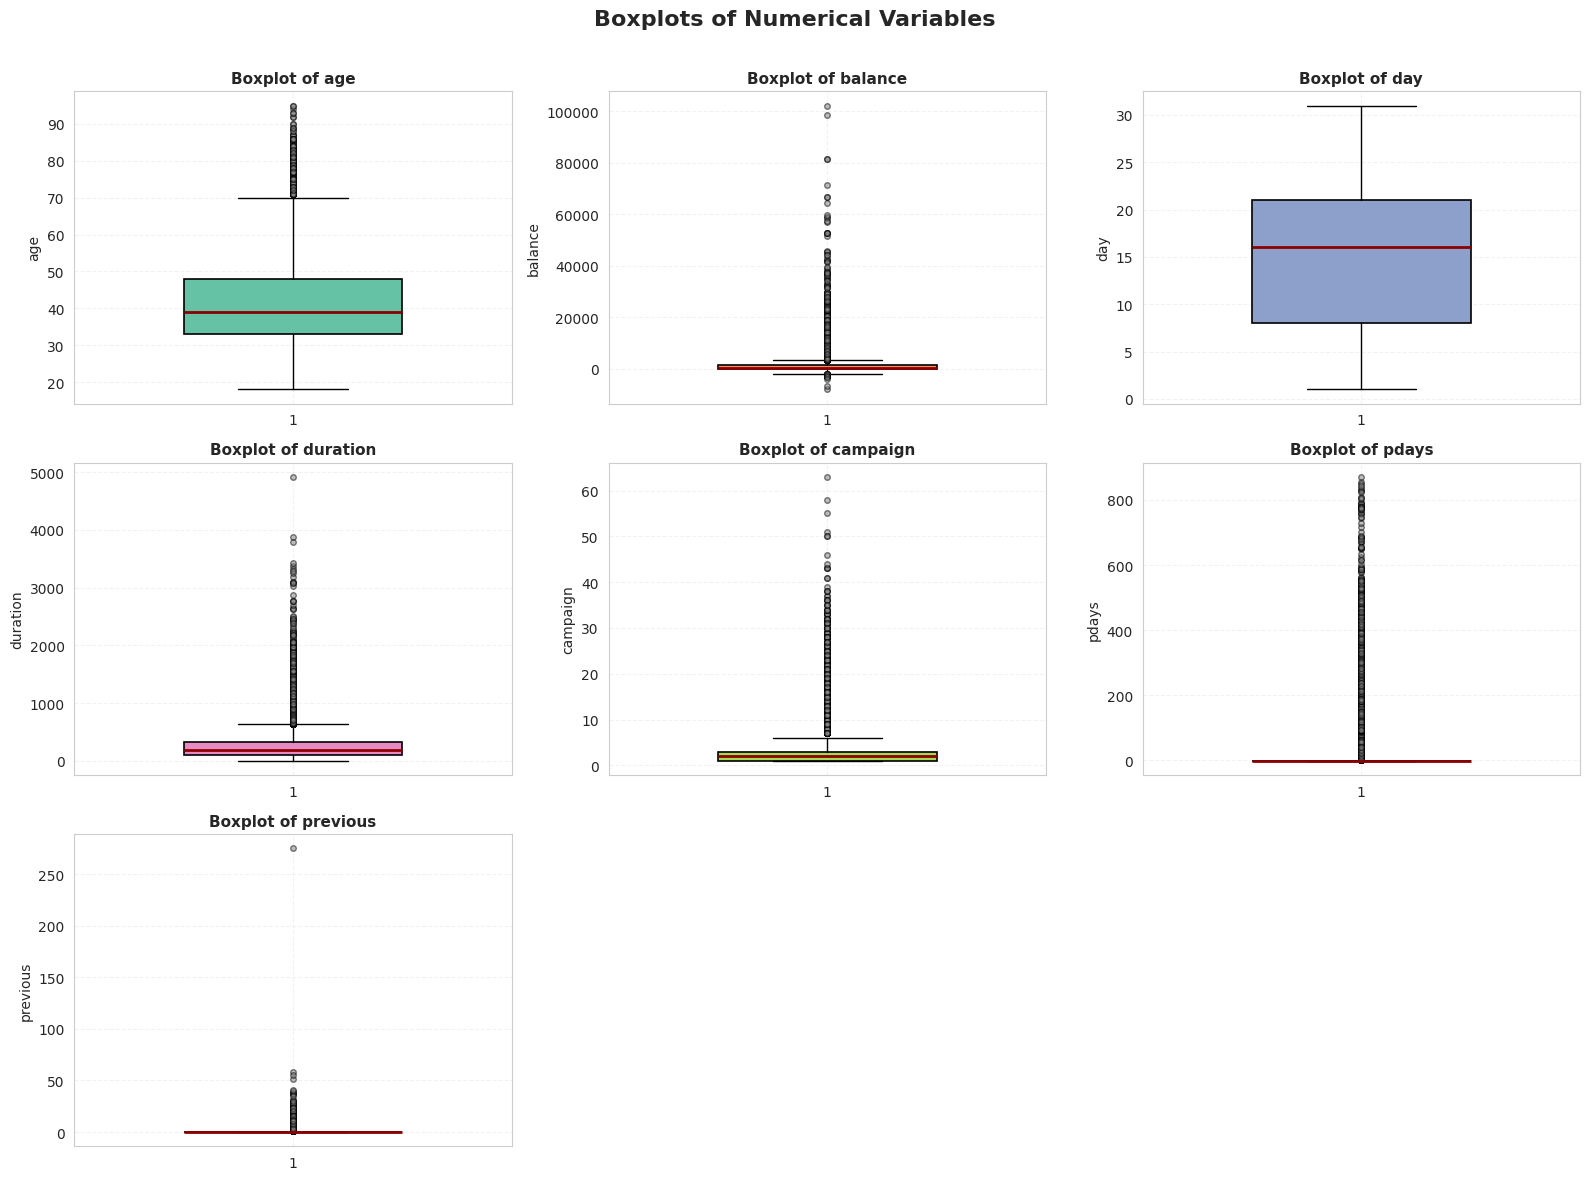

In [24]:
# boxplots of numerical variables

import math

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f',
          '#e5c494', '#b3b3b3', '#1f78b4', '#33a02c', '#fb9a99', '#cab2d6']

for i, col in enumerate(numerical_features):
    bp = axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=colors[i % len(colors)], edgecolor='black', linewidth=1.2),
        medianprops=dict(color='darkred', linewidth=2),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
    )

    axes[i].set_title(f"Boxplot of {col}", fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.25, linestyle='--')

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## **5.3** Compare numerical features by target class

This section compares the mean and median values of numerical variables for customers who subscribed and those who did not subscribe. This helps identify whether numerical features show different patterns across the two classes.

In [25]:
# Mean and median by target class

mean_by_target = df.groupby("y")[numerical_features].mean().T
median_by_target = df.groupby("y")[numerical_features].median().T

print("Mean values by target class:")
display(mean_by_target)

print("\nMedian values by target class:")
display(median_by_target)

Mean values by target class:


y,no,yes
age,40.838986,41.670070
balance,1303.714969,1804.267915
day,15.892290,15.158253
duration,221.182806,537.294574
campaign,2.846350,2.141047
pdays,36.421372,68.702968
previous,0.502154,1.170354



Median values by target class:


y,no,yes
age,39.0,38.0
balance,417.0,733.0
day,16.0,15.0
duration,164.0,426.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0


## **5.4** Bar chart comparison of means by target class

This plot compares the average values of the numerical features across the target classes. It provides a quick visual indication of which variables may separate subscribers from non-subscribers.

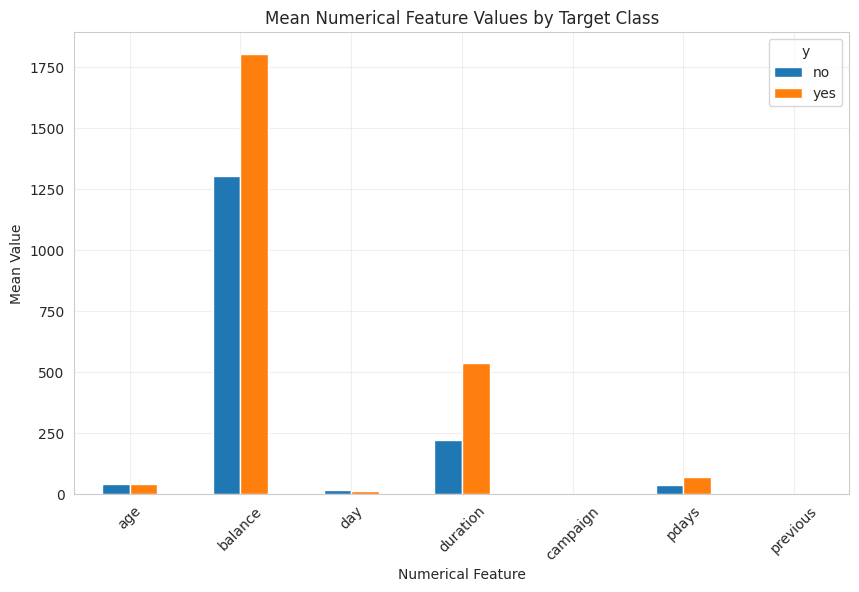

In [26]:
# Plot mean comparison by target class

mean_by_target.plot(kind="bar", figsize=(10, 6))
plt.title("Mean Numerical Feature Values by Target Class")
plt.xlabel("Numerical Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## **5.5** Numerical feature correlation matrix

This section examines linear relationships between the numerical variables using a correlation matrix. Strong correlations may indicate redundancy or interaction between features.

Correlation matrix:


,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


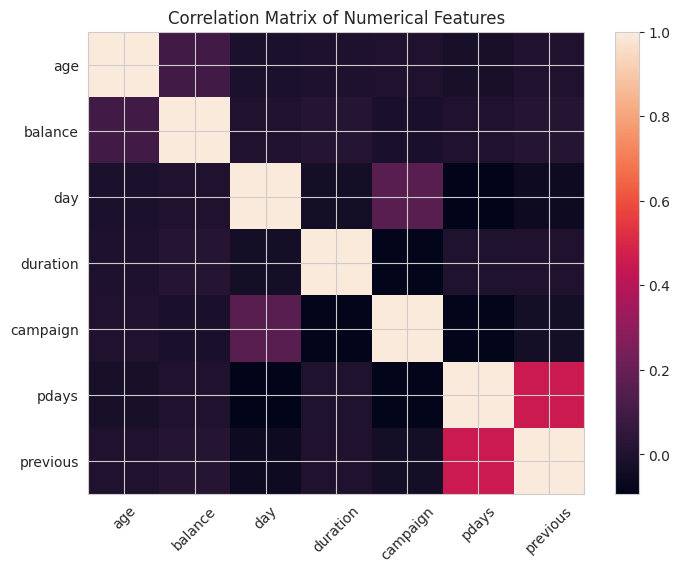

In [27]:
# Correlation matrix

corr_matrix = df[numerical_features].corr()

print("Correlation matrix:")
display(corr_matrix)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix of Numerical Features")
plt.show()